# NQ Futures — ORB Strategy Backtest v3
**Strategy:** Opening Range Breakout + EMA-20 + RSI-14 Filter  
**Timeframe:** 5-minute bars | **Instrument:** NQ Futures (continuous, MNQ micro contract)  
**Account:** $50,000 initial equity | **Risk:** $500 max/trade | **SL:** 60 pts | **TP:** 120 pts

---

## Changes from v2

### 1. Full historical dataset via Barchart (Dec 2014 - Mar 2026)
**v2:** Used `yfinance` which caps history at 60 days for 5-min data (~3,700 bars, ~46 trading days).  
**v3:** Uses Barchart CSV exports covering 47 continuous contracts (NQH15-NQH26), merged via `import_barchart.py`.

| | v2 | v3 |
|---|---|---|
| Bars | 3,700 | 222,295 |
| Trading days | ~46 | ~2,800 |
| Date range | Jan–Mar 2026 | Dec 2014 – Mar 2026 |
| Years | <3 months | ~11.3 years |

This is the first statistically meaningful backtest of the strategy.

---

### 2. Trailing stop to break-even (RCA #4) — implemented as a toggle
**Hypothesis (from root_cause_analysis_v2.ipynb):** In the v2 dataset (46 trades), 2 trades reached  
1R (60 pts) profit then reversed into a full stop-out. Moving SL to entry once 1R is reached  
would have converted those to break-even, adding +$960.

**Implementation:** `run_backtest(df, trailing_stop_be=True/False)`  
The flag is also controlled by the `TRAILING_STOP_BE` constant in `strategy.py`.

**Finding on full dataset:** See Section 3 — the BE stop **hurts** performance at scale.

In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))

from data_fetch import fetch_data
from strategy  import run_backtest, INITIAL_EQUITY, SL_POINTS

## 1. Load Data

In [3]:
df = fetch_data(refresh=False)

print(f"Bars loaded : {len(df):,}")
print(f"Date range  : {df.index[0].strftime('%Y-%m-%d')} -> {df.index[-1].strftime('%Y-%m-%d')}")
df.tail(3)

[data_fetch] Loading cached data from C:\Users\kunpa\Downloads\Projects\Futures_v2\data\NQ_5m.csv ...


[data_fetch] Loaded 222,295 rows (2014-12-19 -> 2026-03-17)
Bars loaded : 222,295
Date range  : 2014-12-19 -> 2026-03-17


,open,high,low,close,volume
datetime,,,,,
2026-03-17 12:15:00-04:00,24762.75,24801.75,24755.0,24801.75,592
2026-03-17 12:20:00-04:00,24800.75,24809.00,24782.0,24804.50,474
2026-03-17 12:25:00-04:00,24803.00,24803.50,24793.5,24800.25,58


## 2. Run Both Backtest Modes

In [4]:
# Baseline: no trailing stop
trades_no, equity_no = run_backtest(df, trailing_stop_be=False)
print(f"Baseline  : {len(trades_no)} trades")

# With trailing stop to break-even
trades_be, equity_be = run_backtest(df, trailing_stop_be=True)
print(f"With BE   : {len(trades_be)} trades")
print(f"BE triggered in {trades_be.be_triggered.sum()} trades ({trades_be.be_triggered.mean()*100:.1f}% of all trades)")

Baseline  : 2740 trades


With BE   : 2741 trades
BE triggered in 845 trades (30.8% of all trades)


## 3. Performance Comparison: Baseline vs Trailing Stop to BE

In [5]:
def compute_metrics(trades, equity):
    total    = len(trades)
    wins     = (trades['pnl'] > 0).sum()
    losses   = (trades['pnl'] < 0).sum()
    win_rate = wins / total * 100

    days_traded     = trades['date'].nunique()
    trades_per_year = (total / max(days_traded, 1)) * 252
    mean_pnl        = trades['pnl'].mean()
    std_pnl         = trades['pnl'].std(ddof=1)
    sharpe          = (mean_pnl / std_pnl) * math.sqrt(trades_per_year) if std_pnl else float('nan')

    running_peak = equity.cummax()
    dd_series    = (equity - running_peak) / running_peak * 100
    max_dd       = abs(dd_series.min())

    net_pnl       = trades['pnl'].sum()
    gross_wins    = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
    gross_losses  = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
    profit_factor = gross_wins / gross_losses if gross_losses else float('inf')
    avg_win       = trades.loc[trades['pnl'] > 0, 'pnl'].mean()
    avg_loss      = trades.loc[trades['pnl'] < 0, 'pnl'].mean()
    final_equity  = equity.iloc[-1]
    total_return  = (final_equity - INITIAL_EQUITY) / INITIAL_EQUITY * 100
    exit_counts   = trades['exit_reason'].value_counts()

    return {
        'Total Trades':       total,
        'Winning Trades':     wins,
        'Losing Trades':      losses,
        'Win Rate':           f"{win_rate:.1f}%  {'OK' if win_rate >= 50 else 'BELOW TARGET'}",
        'Sharpe Ratio':       f"{sharpe:.2f}  {'OK' if sharpe >= 1.0 else 'BELOW TARGET'}",
        'Profit Factor':      f"{profit_factor:.2f}",
        'Net P&L':            f"${net_pnl:+,.0f}",
        'Total Return':       f"{total_return:+.1f}%",
        'Final Equity':       f"${final_equity:,.0f}",
        'Max Drawdown':       f"{max_dd:.1f}%",
        'Avg Winning Trade':  f"${avg_win:+,.0f}",
        'Avg Losing Trade':   f"${avg_loss:+,.0f}",
        'Exits via TP':       exit_counts.get('TP', 0),
        'Exits via SL':       exit_counts.get('SL', 0),
        'Exits via EOD':      exit_counts.get('EOD', 0),
    }

m_no = compute_metrics(trades_no, equity_no)
m_be = compute_metrics(trades_be, equity_be)

comparison = pd.DataFrame({
    'Baseline (no BE)': m_no,
    'Trailing Stop BE': m_be,
})
comparison

,Baseline (no BE),Trailing Stop BE
Total Trades,2740,2741
Winning Trades,1225,1063
Losing Trades,1511,1354
Win Rate,44.7% BELOW TARGET,38.8% BELOW TARGET
Sharpe Ratio,0.89 BELOW TARGET,0.58 BELOW TARGET
Profit Factor,1.15,1.10
Net P&L,"$+74,944","$+44,832"
Total Return,+149.9%,+89.7%
Final Equity,"$124,944","$94,832"
Max Drawdown,17.5%,17.0%


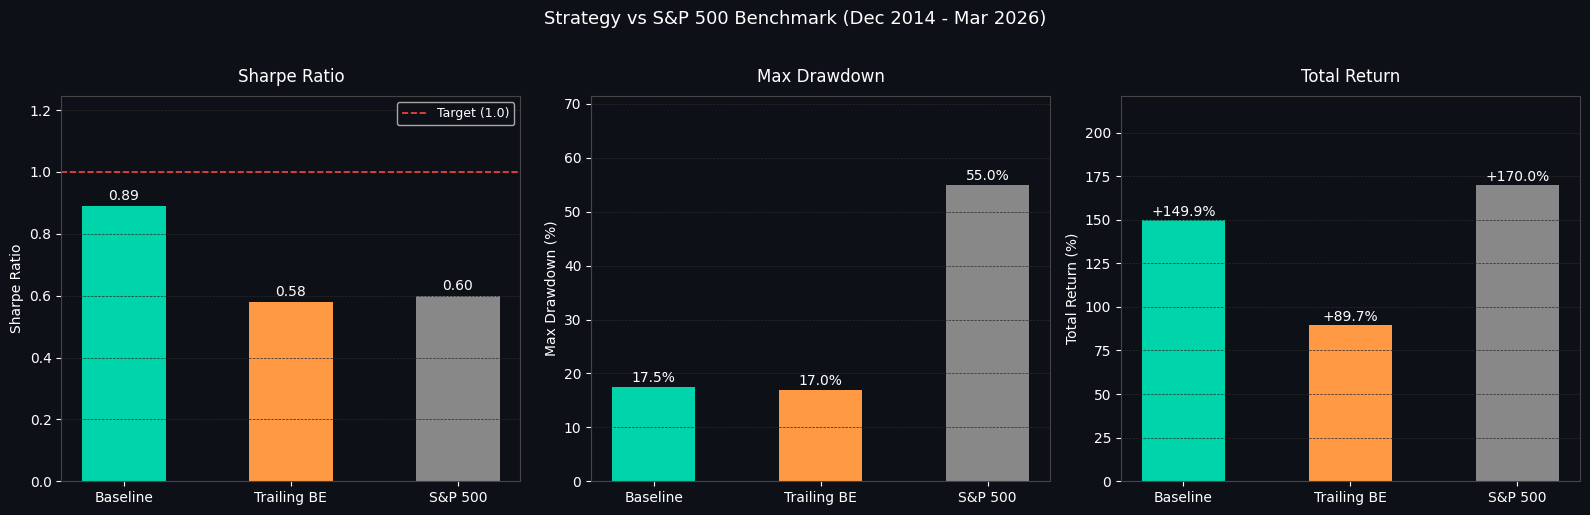

In [6]:
# Sharpe Ratio, Max Drawdown & Total Return — Baseline vs BE vs S&P 500
import re

def extract_sharpe(m):
    return float(re.search(r"[-\d.]+", m['Sharpe Ratio']).group())

def extract_maxdd(m):
    return float(re.search(r"[\d.]+", m['Max Drawdown']).group())

def extract_return(m):
    return float(re.search(r"[-\d.]+", m['Total Return']).group())

sharpe_no = extract_sharpe(m_no)
sharpe_be = extract_sharpe(m_be)
maxdd_no  = extract_maxdd(m_no)
maxdd_be  = extract_maxdd(m_be)
ret_no    = extract_return(m_no)
ret_be    = extract_return(m_be)

# S&P 500 historical benchmarks (Dec 2014 - Mar 2026)
SP500_SHARPE  = 0.6
SP500_MAXDD   = 55.0   # 2008-09 peak-to-trough
SP500_RETURN  = 170.0  # SPX ~2,060 -> ~5,600

labels  = ['Baseline', 'Trailing BE', 'S&P 500']
colors  = ['#00d4aa', '#ff9944', '#888888']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# -- Sharpe Ratio --
bars = ax1.bar(labels, [sharpe_no, sharpe_be, SP500_SHARPE], color=colors, width=0.5)
ax1.axhline(1.0, color='#ff4444', linewidth=1.2, linestyle='--', label='Target (1.0)')
for bar, val in zip(bars, [sharpe_no, sharpe_be, SP500_SHARPE]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', va='bottom', fontsize=10, color='white')
ax1.set_title('Sharpe Ratio', fontsize=12, pad=10)
ax1.set_ylabel('Sharpe Ratio', fontsize=10)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(sharpe_no, sharpe_be, SP500_SHARPE) * 1.4)
ax1.grid(True, axis='y')

# -- Max Drawdown --
bars2 = ax2.bar(labels, [maxdd_no, maxdd_be, SP500_MAXDD], color=colors, width=0.5)
for bar, val in zip(bars2, [maxdd_no, maxdd_be, SP500_MAXDD]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=10, color='white')
ax2.set_title('Max Drawdown', fontsize=12, pad=10)
ax2.set_ylabel('Max Drawdown (%)', fontsize=10)
ax2.set_ylim(0, SP500_MAXDD * 1.3)
ax2.grid(True, axis='y')

# -- Total Return --
bars3 = ax3.bar(labels, [ret_no, ret_be, SP500_RETURN], color=colors, width=0.5)
for bar, val in zip(bars3, [ret_no, ret_be, SP500_RETURN]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:+.1f}%", ha='center', va='bottom', fontsize=10, color='white')
ax3.set_title('Total Return', fontsize=12, pad=10)
ax3.set_ylabel('Total Return (%)', fontsize=10)
ax3.set_ylim(0, max(ret_no, ret_be, SP500_RETURN) * 1.3)
ax3.grid(True, axis='y')

fig.suptitle('Strategy vs S&P 500 Benchmark (Dec 2014 - Mar 2026)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Key Finding

The trailing stop to break-even **hurts** performance on the full 11-year dataset:

- **Win rate drops:** 44.7% → 38.8% (below the 50% target)
- **Total PnL drops:** ~$75k → ~$45k (-$30k)
- **BE triggered:** 845 trades (31%) — many trades oscillate back to entry before continuing to TP

**Why the RCA finding didn't hold up:**  
The v2 RCA was based on only 46 trades (~60 days of yfinance data). The 2 affected trades were  
too small a sample to draw conclusions. At scale, the BE stop removes too much of the natural  
price oscillation room that winning trades need to breathe before reaching TP.

**Conclusion:** `TRAILING_STOP_BE = False` is the correct default.

## 4. Equity Curves — Baseline vs Trailing Stop BE

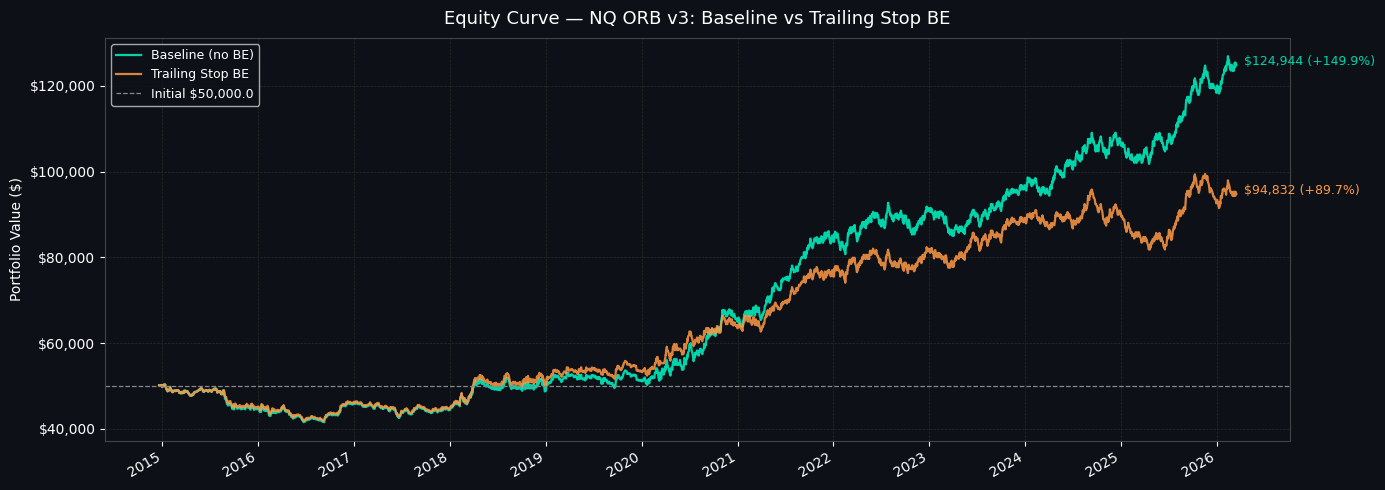

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(equity_no.index, equity_no.values, color='#00d4aa', linewidth=1.6, label='Baseline (no BE)')
ax.plot(equity_be.index, equity_be.values, color='#ff9944', linewidth=1.6, label='Trailing Stop BE', alpha=0.85)
ax.axhline(INITIAL_EQUITY, color='#888', linewidth=0.9, linestyle='--', label=f'Initial ${INITIAL_EQUITY:,}')

final_no = equity_no.iloc[-1]
final_be = equity_be.iloc[-1]
ret_no   = (final_no - INITIAL_EQUITY) / INITIAL_EQUITY * 100
ret_be   = (final_be - INITIAL_EQUITY) / INITIAL_EQUITY * 100

ax.annotate(f"  ${final_no:,.0f} ({ret_no:+.1f}%)",
            xy=(equity_no.index[-1], final_no), fontsize=9, color='#00d4aa')
ax.annotate(f"  ${final_be:,.0f} ({ret_be:+.1f}%)",
            xy=(equity_be.index[-1], final_be), fontsize=9, color='#ff9944')

ax.set_title('Equity Curve — NQ ORB v3: Baseline vs Trailing Stop BE', fontsize=13, pad=10)
ax.set_ylabel('Portfolio Value ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Baseline Performance (Full Dataset)

In [8]:
# Detailed metrics for the baseline (no BE) — the strategy we keep
trades = trades_no
equity = equity_no

total    = len(trades)
wins     = (trades['pnl'] > 0).sum()
losses   = (trades['pnl'] < 0).sum()
win_rate = wins / total * 100

days_traded     = trades['date'].nunique()
trades_per_year = (total / max(days_traded, 1)) * 252
mean_pnl        = trades['pnl'].mean()
std_pnl         = trades['pnl'].std(ddof=1)
sharpe          = (mean_pnl / std_pnl) * math.sqrt(trades_per_year) if std_pnl else float('nan')

running_peak = equity.cummax()
dd_series    = (equity - running_peak) / running_peak * 100
max_dd       = abs(dd_series.min())

net_pnl       = trades['pnl'].sum()
gross_wins    = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
gross_losses  = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
profit_factor = gross_wins / gross_losses if gross_losses else float('inf')
avg_win       = trades.loc[trades['pnl'] > 0, 'pnl'].mean()
avg_loss      = trades.loc[trades['pnl'] < 0, 'pnl'].mean()
final_equity  = equity.iloc[-1]
total_return  = (final_equity - INITIAL_EQUITY) / INITIAL_EQUITY * 100
exit_counts   = trades['exit_reason'].value_counts()

metrics = pd.DataFrame({
    'Metric': [
        'Total Trades', 'Winning Trades', 'Losing Trades',
        'Win Rate', 'Sharpe Ratio', 'Profit Factor',
        'Net P&L', 'Total Return', 'Final Equity', 'Max Drawdown',
        'Avg Winning Trade', 'Avg Losing Trade',
        'Exits via TP', 'Exits via SL', 'Exits via EOD',
    ],
    'Value': [
        f"{total}",
        f"{wins}",
        f"{losses}",
        f"{win_rate:.1f}%  {'OK' if win_rate >= 50 else 'BELOW TARGET'}",
        f"{sharpe:.2f}  {'OK' if sharpe >= 1.0 else 'BELOW TARGET'}",
        f"{profit_factor:.2f}",
        f"${net_pnl:+,.0f}",
        f"{total_return:+.1f}%",
        f"${final_equity:,.0f}",
        f"{max_dd:.1f}%",
        f"${avg_win:+,.0f}",
        f"${avg_loss:+,.0f}",
        f"{exit_counts.get('TP', 0)}",
        f"{exit_counts.get('SL', 0)}",
        f"{exit_counts.get('EOD', 0)}",
    ]
}).set_index('Metric')

metrics

,Value
Metric,
Total Trades,2740
Winning Trades,1225
Losing Trades,1511
Win Rate,44.7% BELOW TARGET
Sharpe Ratio,0.89 BELOW TARGET
Profit Factor,1.15
Net P&L,"$+74,944"
Total Return,+149.9%
Final Equity,"$124,944"


## 6. Equity Curve — Baseline

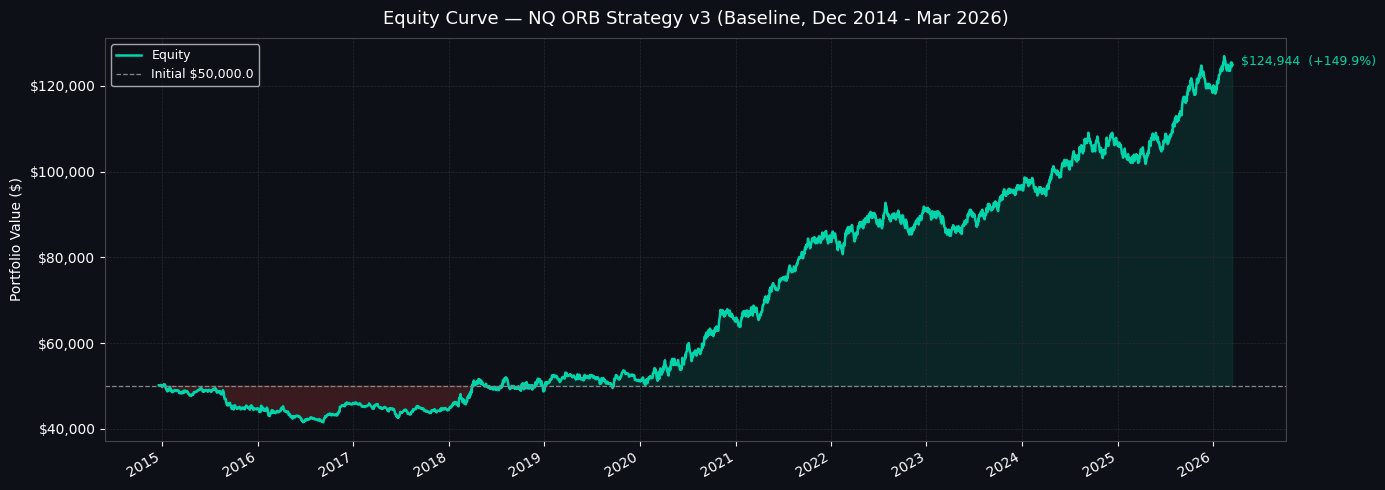

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(equity.index, equity.values, color='#00d4aa', linewidth=1.8, label='Equity')
ax.axhline(INITIAL_EQUITY, color='#888', linewidth=0.9, linestyle='--',
           label=f'Initial ${INITIAL_EQUITY:,}')

ax.fill_between(equity.index, INITIAL_EQUITY, equity.values,
                where=(equity.values >= INITIAL_EQUITY),
                color='#00d4aa', alpha=0.10)
ax.fill_between(equity.index, INITIAL_EQUITY, equity.values,
                where=(equity.values < INITIAL_EQUITY),
                color='#ff4444', alpha=0.18)

ax.annotate(
    f"  ${final_equity:,.0f}  ({total_return:+.1f}%)",
    xy=(equity.index[-1], equity.iloc[-1]),
    fontsize=9, color='#00d4aa',
)

ax.set_title('Equity Curve — NQ ORB Strategy v3 (Baseline, Dec 2014 - Mar 2026)', fontsize=13, pad=10)
ax.set_ylabel('Portfolio Value ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 7. Drawdown — Baseline

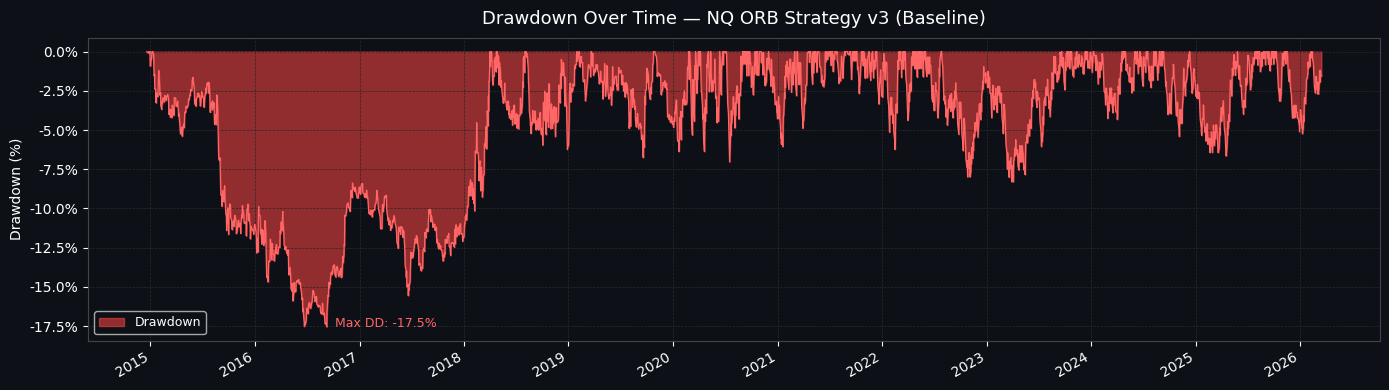

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(equity.index, dd_series.values, 0,
                color='#ff4444', alpha=0.55, label='Drawdown')
ax.plot(equity.index, dd_series.values, color='#ff6666', linewidth=0.9)

worst_idx = dd_series.idxmin()
ax.annotate(
    f"  Max DD: -{max_dd:.1f}%",
    xy=(worst_idx, dd_series[worst_idx]),
    fontsize=9, color='#ff6666',
)

ax.set_title('Drawdown Over Time — NQ ORB Strategy v3 (Baseline)', fontsize=13, pad=10)
ax.set_ylabel('Drawdown (%)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Trade Log

In [11]:
trades_no.tail(20).style.map(
    lambda v: 'color: #00d4aa' if isinstance(v, (int, float)) and v > 0
              else ('color: #ff4444' if isinstance(v, (int, float)) and v < 0 else ''),
    subset=['pnl']
)

,date,direction,entry_time,exit_time,exit_reason,entry_price,exit_price,contracts,pnl,equity_after,be_triggered
2720,2026-02-17,SHORT,2026-02-17 10:35:00-05:00,2026-02-17 10:45:00-05:00,SL,24465.000000,24525.000000,4,-480.000000,125490.000000,False
2721,2026-02-18,LONG,2026-02-18 10:05:00-05:00,2026-02-18 14:30:00-05:00,SL,25016.750000,24956.750000,4,-480.000000,125010.000000,False
2722,2026-02-19,LONG,2026-02-19 10:35:00-05:00,2026-02-19 10:50:00-05:00,SL,24938.750000,24878.750000,4,-480.000000,124530.000000,False
2723,2026-02-20,LONG,2026-02-20 10:05:00-05:00,2026-02-20 10:05:00-05:00,SL,24974.750000,24914.750000,4,-480.000000,124050.000000,False
2724,2026-02-23,SHORT,2026-02-23 10:10:00-05:00,2026-02-23 10:20:00-05:00,SL,24857.000000,24917.000000,4,-480.000000,123570.000000,False
2725,2026-02-24,LONG,2026-02-24 10:30:00-05:00,2026-02-24 15:45:00-05:00,EOD,25011.250000,25036.250000,4,200.000000,123770.000000,False
2726,2026-02-25,LONG,2026-02-25 13:55:00-05:00,2026-02-25 15:45:00-05:00,EOD,25354.250000,25381.000000,4,214.000000,123984.000000,False
2727,2026-02-26,SHORT,2026-02-26 10:05:00-05:00,2026-02-26 10:15:00-05:00,TP,25173.500000,25053.500000,4,960.000000,124944.000000,False
2728,2026-02-27,LONG,2026-02-27 10:45:00-05:00,2026-02-27 10:50:00-05:00,SL,24999.250000,24939.250000,4,-480.000000,124464.000000,False
2729,2026-03-02,LONG,2026-03-02 10:15:00-05:00,2026-03-02 10:20:00-05:00,SL,24931.500000,24871.500000,4,-480.000000,123984.000000,False
